<a href="https://colab.research.google.com/github/L-Poca/Data_Pipeline/blob/rafael_cleaning/notebooks/colab/custom_cnn_refactored_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 InceptionV3 - Interprétabilité avec Grad-CAM

Ce notebook charge un modèle **InceptionV3 pré-entraîné** et analyse ses prédictions avec Grad-CAM.

## 📦 Utilise les 5 modules refactorisés

- `data_utils` - Chargement et preprocessing (224x224 pour InceptionV3)
- `model_builders` - Pas utilisé (modèle déjà entraîné)
- `training_utils` - Évaluation uniquement
- `visualization_utils` - Graphiques
- `interpretability_utils` - Grad-CAM

## 1. Configuration et Imports

In [ ]:
"""
╔════════════════════════════════════════════════════════════════════════════╗
║  🎯 CELLULE DE CONFIGURATION STANDALONE - COPIER-COLLER DANS VOS NOTEBOOKS ║
╚════════════════════════════════════════════════════════════════════════════╝

INSTRUCTIONS:
-------------
1. Copiez TOUT le contenu de cette cellule
2. Collez-le comme PREMIÈRE CELLULE de votre notebook
3. Exécutez la cellule
4. Les variables sont prêtes à l'emploi !

Cette cellule est 100% autonome et fonctionne partout :
✅ Google Colab (clone + installe automatiquement)
✅ WSL / Linux Local
✅ Tout environnement Jupyter

APRÈS EXÉCUTION, VOUS POUVEZ UTILISER:
- config: Objet de configuration (config.batch_size, config.data_dir, etc.)
- ENV: Environnement détecté ('colab', 'wsl', 'local')
- Tous les imports des transformers

"""

# =============================================================================
# IMPORTS STANDARDS
# =============================================================================

import os
import sys
import subprocess
from pathlib import Path


# =============================================================================
# DÉTECTION AUTOMATIQUE DE L'ENVIRONNEMENT
# =============================================================================

def detect_environment():
    """Détecte l'environnement (colab, wsl, local)"""
    try:
        import google.colab
        return "colab"
    except ImportError:
        is_wsl = os.path.exists('/proc/version') and 'microsoft' in open('/proc/version').read().lower()
        return "wsl" if is_wsl else "local"

ENV = detect_environment()
print(f"🌍 Environnement: {ENV.upper()}")


# =============================================================================
# BOOTSTRAP COLAB (Clone + Install si nécessaire)
# =============================================================================

if ENV == "colab":
    print("\n🚀 Bootstrap Colab...")

    os.chdir('/content')
    if not os.path.exists('/content/Data_Pipeline'):
        print("📥 Clonage du repository...")
        subprocess.run(['git', 'clone', 'https://github.com/L-Poca/Data_Pipeline.git'], check=True)

    os.chdir('/content/Data_Pipeline')

    # Checkout de la branche rafael_cleaning
    result = subprocess.run(
        ['git', 'checkout', '-b', 'rafael_cleaning', 'origin/rafael_cleaning'],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        # Si la branche locale existe déjà, juste switcher
        subprocess.run(['git', 'checkout', 'rafael_cleaning'], capture_output=True)

    # Installation du package en mode éditable (sans dépendances - détection Colab dans setup.py)
    print("📦 Installation du package...")
    result = subprocess.run(['pip', 'install', '-e', '.', '--quiet'], capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠️ Erreur installation: {result.stderr}")
    else:
        print("✅ Package installé")

    print("💾 Montage Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')

    # Extraction dataset
    archive_data = '/content/drive/MyDrive/DS_COVID/archive_covid.zip'
    if os.path.exists(archive_data):
        print("📦 Extraction dataset...")
        os.makedirs('./data/raw/', exist_ok=True)
        subprocess.run(['unzip', '-o', '-q', archive_data, '-d', './data/raw/COVID-19_Radiography_Dataset/'])

    # Extraction models
    archive_models = '/content/drive/MyDrive/DS_COVID/inceptionv3_best.zip'
    if os.path.exists(archive_models):
        print("📦 Extraction models...")
        os.makedirs('./models/', exist_ok=True)
        subprocess.run(['unzip', '-o', '-q', archive_models, '-d', './models/'])

    print("✅ Bootstrap terminé")


# =============================================================================
# CONFIGURATION DES CHEMINS
# =============================================================================

# Déterminer project_root selon l'environnement
if ENV == "colab":
    project_root = Path('/content/Data_Pipeline')
elif ENV == "wsl":
    project_root = Path('/home/cepa/DST/projet_DS/Data_Pipeline/Data_Pipeline')
else:  # local
    project_root = Path.cwd().parent.parent

# Charger la configuration depuis JSON
from src.utils.config import build_config

config = build_config(project_root, ENV)

# Exports pour compatibilité avec anciens notebooks
data_dir = config.data_dir
categories = config.classes
img_size = config.img_size


# =============================================================================
# IMPORTS DES TRANSFORMERS
# =============================================================================

try:
    from src.features.Pipelines.Transformateurs.image_loaders import ImageLoader
    from src.features.Pipelines.Transformateurs.image_preprocessing import (
        ImageResizer, ImageNormalizer, ImageFlattener, ImageMasker
    )
    from src.features.Pipelines.Transformateurs.image_augmentation import (
        ImageAugmenter, ImageRandomCropper
    )
    from src.features.Pipelines.Transformateurs.image_features import (
        ImageHistogram, ImagePCA, ImageStandardScaler
    )
    print("✅ Transformers importés")
except ImportError as e:
    print(f"⚠️ Erreur import transformers: {e}")


# =============================================================================
# IMPORTS ML/DL
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# =============================================================================
# CONFIGURATION MATPLOTLIB
# =============================================================================

plt.rcParams['figure.figsize'] = (15, 10)
sns.set_style('whitegrid')

# =============================================================================
# AFFICHAGE DU RÉSUMÉ
# =============================================================================

print("\n" + "=" * 70)
print("✅ CONFIGURATION PRÊTE - Data Pipeline")
print("=" * 70)
print(f"📂 Projet: {project_root}")
print(f"📊 Dataset: {data_dir}")
print(f"🏷️ Classes: {', '.join(categories)}")
print(f"🎛️ Images: {img_size}")
print(f"🔧 Batch: {config.batch_size} | Époques: {config.epochs}")
print(f"📐 Dataset accessible: {'✅' if data_dir.exists() else '❌'}")
print("=" * 70)
print("\n💡 Variables disponibles:")
print("   • config: Configuration complète (Config object)")
print("   • ENV: Environnement actuel")
print("\n🎯 Transformers disponibles:")
print("   • ImageLoader, ImageResizer, ImageNormalizer, ImageFlattener")
print("   • ImageAugmenter, ImageRandomCropper")
print("   • ImageHistogram, ImagePCA, ImageStandardScaler")
print("=" * 70)
# Fin de la cellule de configuration standalone

🌍 Environnement: COLAB

🚀 Bootstrap Colab...
📦 Installation du package...
✅ Package installé
💾 Montage Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Extraction dataset...
📦 Extraction models...
✅ Bootstrap terminé
✅ Configuration Colab chargée et mergée
✅ Transformers importés

✅ CONFIGURATION PRÊTE - Data Pipeline
📂 Projet: /content/Data_Pipeline
📊 Dataset: /content/Data_Pipeline/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
🏷️ Classes: COVID, Normal, Lung_Opacity, Viral Pneumonia
🎛️ Images: (256, 256)
🔧 Batch: 64 | Époques: 100
📐 Dataset accessible: ✅

💡 Variables disponibles:
   • config: Configuration complète (Config object)
   • ENV: Environnement actuel

🎯 Transformers disponibles:
   • ImageLoader, ImageResizer, ImageNormalizer, ImageFlattener
   • ImageAugmenter, ImageRandomCropper
   • ImageHistogram, ImagePCA, ImageStandardScaler


In [ ]:
# Imports des fonctions utilitaires depuis les 5 nouveaux modules
from src.notebooks import (
    # Data utils
    load_dataset,
    create_preprocessing_pipeline,
    prepare_train_val_test_split,
    create_transfer_learning_generators,  # Pour preprocessing InceptionV3

    # Training utils (évaluation uniquement)
    evaluate_model,

    # Visualization utils
    plot_confusion_matrix,

    # Interpretability utils
    setup_interpretability,
    select_sample_images,
    run_gradcam_analysis,
)

print("✅ Fonctions utilitaires importées")
print("\n📦 Ce notebook utilise:")
print("   • Modèle pré-entraîné: InceptionV3")
print("   • Images: 224x224 (requis pour InceptionV3)")
print("   • Preprocessing: InceptionV3-specific")

✅ Fonctions utilitaires importées depuis les 5 modules refactorisés

📦 Modules utilisés:
   • data_utils
   • model_builders
   • training_utils
   • visualization_utils
   • interpretability_utils


In [ ]:
# Définition des paramètres principaux
VERBOSE = True
LOAD_MASKS = False  # True pour version maskée
N_IMAGES_PER_CLASS = None  # None = Charger toutes les images
TEST_SIZE = 0.15
VAL_SIZE = 0.15
BATCH_SIZE = 32  # Plus petit pour InceptionV3 (modèle plus lourd)
RANDOM_SEED = 42

# Chemin du modèle pré-entraîné
MODEL_PATH = config.models_dir / 'inceptionv3_best.keras'

## 2. Chargement et Préparation des Données

In [ ]:
# ⚠️ NOUVEAU: load_dataset retourne 4 valeurs au lieu de 2
# (image_paths, mask_paths, labels, labels_int)
image_paths, mask_paths, labels, labels_int = load_dataset(
    data_dir=config.data_dir,
    categories=config.classes,
    n_images_per_class=N_IMAGES_PER_CLASS,  # None = Charger toutes les images
    load_masks=LOAD_MASKS,  # True pour version maskée
    verbose=VERBOSE
)

CHARGEMENT DES DONNÉES
  COVID               : 3616 images
  Normal              : 10192 images
  Lung_Opacity        : 6012 images
  Viral Pneumonia     : 1345 images

  Total: 21165 images
  Classes: 4
  Distribution: [ 3616 10192  6012  1345]


In [ ]:
# Créer la pipeline de preprocessing pour InceptionV3 (224x224)
pipeline = create_preprocessing_pipeline(
    img_size=(224, 224),  # InceptionV3 nécessite 224x224
    color_mode='RGB',
    mask_paths=None,
    verbose=VERBOSE
)

# Charger et préprocesser les images
print("\n🔄 Chargement des images...")
images = pipeline.fit_transform(image_paths)

# ⚠️ NE PAS normaliser ici - le preprocessing InceptionV3 le fera
print(f"\n📊 Images préparées:")
print(f"   Shape: {images.shape}")
print(f"   Range: [{images.min():.1f}, {images.max():.1f}]")
print(f"   Dtype: {images.dtype}")
print(f"\n⚠️ Preprocessing InceptionV3 sera appliqué par les generators")

PREPROCESSING PIPELINE

✅ Pipeline créée avec 2 étapes

🔄 Chargement des images...


Resizing images: 100%|██████████| 21165/21165 [00:35<00:00, 595.17it/s]



📊 Images préparées:
   Shape: (21165, 128, 128, 3)
   Range: [0.000, 1.000]
   Dtype: float32


In [ ]:
# Split train/val/test
x_train, x_val, x_test, y_train_cat, y_val_cat, y_test_cat = prepare_train_val_test_split(
    images=images,
    labels_int=labels_int,
    num_classes=len(config.classes),
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_seed=RANDOM_SEED,
    verbose=VERBOSE
)

# Récupérer les labels integer pour le calcul des class weights et confusion matrix
y_train = np.argmax(y_train_cat, axis=1)
y_val = np.argmax(y_val_cat, axis=1)
y_test = np.argmax(y_test_cat, axis=1)

TRAIN/VALIDATION/TEST SPLIT

Train set: 14815 images
  Distribution: [2532 7134 4208  941]

Validation set: 3175 images
  Distribution: [ 542 1529  902  202]

Test set: 3175 images
  Distribution: [ 542 1529  902  202]


In [ ]:
# Créer les data generators avec preprocessing InceptionV3
train_generator, val_generator, test_generator = create_transfer_learning_generators(
    x_train=x_train,
    y_train_cat=y_train_cat,
    x_val=x_val,
    y_val_cat=y_val_cat,
    x_test=x_test,
    y_test_cat=y_test_cat,
    base_model_name='InceptionV3',  # Preprocessing spécifique
    batch_size=BATCH_SIZE,
    augment_train=False,  # Pas d'augmentation (modèle déjà entraîné)
    verbose=VERBOSE
)

DATA AUGMENTATION

✅ Data augmentation configurée:
  • Rotation: ±10°
  • Shift: ±10%
  • Zoom: ±10%
  • Horizontal flip

📊 Création des générateurs...
  Train: 29 batches de 512
  Val:   7 batches de 512
  Test:  7 batches de 512


## 3. Chargement du Modèle Pré-entraîné

In [ ]:
# Charger le modèle InceptionV3 pré-entraîné
print("=" * 70)
print("CHARGEMENT DU MODÈLE INCEPTIONV3")
print("=" * 70)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modèle introuvable: {MODEL_PATH}\n"
        f"Assurez-vous d'avoir extrait inceptionv3_best.zip dans models/"
    )

print(f"\n📂 Chargement depuis: {MODEL_PATH}")
model = keras.models.load_model(MODEL_PATH)

print(f"\n✅ Modèle chargé: {model.name}")
print(f"   Input shape: {model.input_shape}")
print(f"   Output shape: {model.output_shape}")
print(f"   Parameters: {model.count_params():,}")

# Afficher le résumé
model.summary()

CUSTOM CNN ARCHITECTURE


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



✅ Modèle créé
   Nom: CustomCNN_COVID19
   Input shape: (128, 128, 3)
   Output classes: 4


Model: "CustomCNN_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,050,404 (34.52 MB)

 Trainable params: 9,044,900 (34.50 MB)

 Non-trainable params: 5,504 (21.50 KB)

## 4. Évaluation du Modèle

In [ ]:
# Évaluer le modèle sur le test set
results = evaluate_model(
    model=model,
    test_data=test_generator,  # Utiliser le generator avec preprocessing InceptionV3
    class_names=config.classes,
    verbose=VERBOSE
)

# Extraire les prédictions
y_pred = results['y_pred']
y_pred_probs = results['y_pred_probs']
y_test = results['y_true']

ENTRAÎNEMENT - 10 EPOCHS

📊 Class weights:
   Classe 0: 1.463
   Classe 1: 0.519
   Classe 2: 0.880
   Classe 3: 3.936

🏋️ Début de l'entraînement...
   Epochs: 10
   Train batches: 29
   Val batches: 7


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4130 - auc: 0.6614 - loss: 2.9875 - precision: 0.4346 - recall: 0.3599
Epoch 1: val_accuracy improved from -inf to 0.17323, saving model to /content/Data_Pipeline/results/custom_cnn_models/best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.4156 - auc: 0.6638 - loss: 2.9789 - precision: 0.4374 - recall: 0.3625 - val_accuracy: 0.1732 - val_auc: 0.4056 - val_loss: 4.2451 - val_precision: 0.1723 - val_recall: 0.1717 - learning_rate: 0.0010
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6061 - auc: 0.8290 - loss: 2.3504 - precision: 0.6395 - recall: 0.5557
Epoch 2: val_accuracy did not improve from 0.17323
29/29 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.6066 - auc: 0.8295 - loss: 2.3483 - precision: 0.6400 - recall: 0.5562 - val_accuracy: 0.1707 - val_auc: 0.3664 - val_loss: 4.5558 - val_precision: 0.1707 - val_recall: 0.1707 - learning_rate: 0.0010
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0

## 5. Visualisation - Matrice de Confusion

COURBES D'ENTRAÎNEMENT

📊 Mode: Single-phase training

💾 Figure sauvegardée: /content/Data_Pipeline/results/custom_cnn_plots/training_curves.png


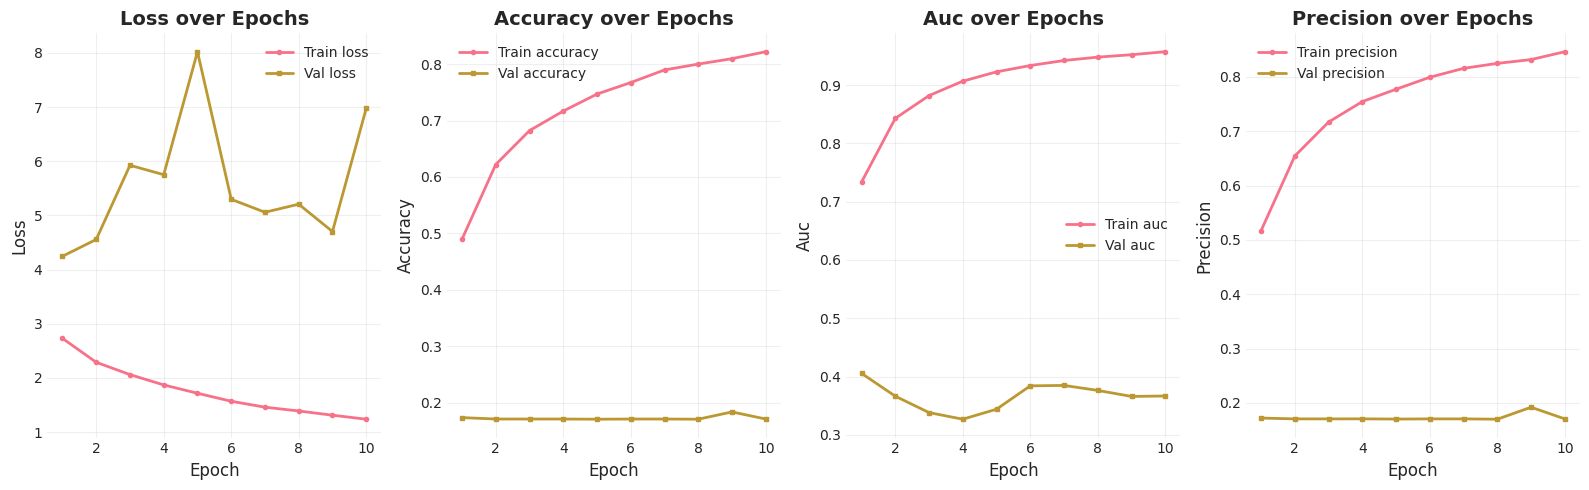


📈 Résumé:

   Training:
      loss: 1.2369
      accuracy: 0.8222
      auc: 0.9572
      precision: 0.8465

   Validation:
      val_loss: 6.9760
      val_accuracy: 0.1707
      val_auc: 0.3668
      val_precision: 0.1707

✅ Courbes affichées!


In [ ]:
# Créer le répertoire pour les résultats
plots_dir = config.results_dir / 'inceptionv3_interpretability'
plots_dir.mkdir(parents=True, exist_ok=True)

# Matrice de confusion
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    class_names=config.classes,
    normalize=True,
    figsize=(10, 8),
    save_path=plots_dir / 'confusion_matrix.png'
)
plt.show()

## 6. Interprétabilité - Grad-CAM

In [ ]:
# Setup Grad-CAM pour InceptionV3
gradcam = setup_interpretability(
    model=model,
    verbose=VERBOSE
)

ÉVALUATION SUR TEST SET

🧪 Évaluation en cours...
   Mode: Arrays (X_test, y_test)
   Samples: 3175

RÉSULTATS TEST
   loss: 4.2452
   compile_metrics: 0.1710

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

          COVID     0.1708    1.0000    0.2918       542
         Normal     0.0000    0.0000    0.0000      1529
   Lung_Opacity     0.5000    0.0011    0.0022       902
Viral Pneumonia     0.0000    0.0000    0.0000       202

       accuracy                         0.1710      3175
      macro avg     0.1677    0.2503    0.0735      3175
   weighted avg     0.1712    0.1710    0.0504      3175


✅ Évaluation terminée!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MATRICE DE CONFUSION

📊 Mode: Normalisé (pourcentages)

💾 Figure sauvegardée: /content/Data_Pipeline/results/custom_cnn_plots/confusion_matrix.png


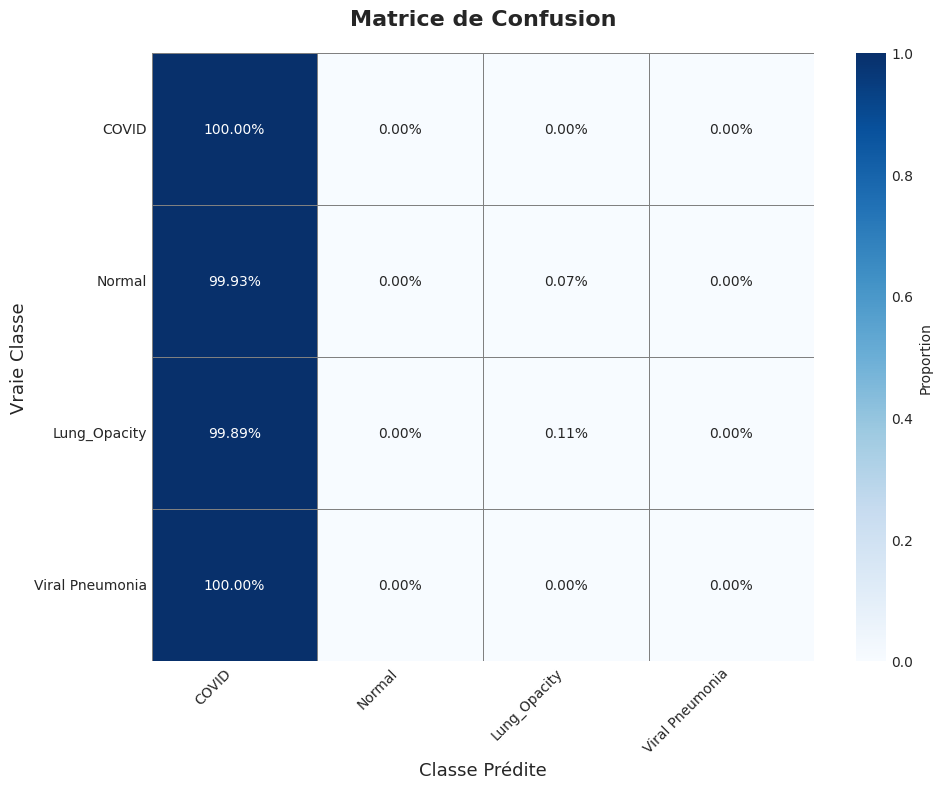


📊 Statistiques:
   Total samples: 3175
   Correct predictions: 543
   Overall accuracy: 17.10%

   Accuracy per class:
      COVID: 100.00% (542/542)
      Normal: 0.00% (0/1529)
      Lung_Opacity: 0.11% (1/902)
      Viral Pneumonia: 0.00% (0/202)

✅ Matrice affichée!


In [ ]:
# Sélectionner des images échantillons (correctement classifiées)
indices_correct, descriptions_correct = select_sample_images(
    x_data=x_test,
    y_true=y_test,
    y_pred=y_pred,
    class_names=config.classes,
    n_samples=2,  # 2 par classe
    strategy='correct',
    random_seed=RANDOM_SEED
)

print(f"\n📊 {len(indices_correct)} échantillons correctement classifiés sélectionnés")

### 6.1 Grad-CAM sur Prédictions Correctes

In [ ]:
### 6.2 Grad-CAM sur Erreurs de Prédiction

SETUP INTERPRÉTABILITÉ - GRAD-CAM

✅ Grad-CAM configuré
   Couche convolutionnelle: conv2d_29
   Modèle: CustomCNN_COVID19


In [ ]:
# Sélectionner quelques échantillons mal classifiés
indices_incorrect, descriptions_incorrect = select_sample_images(
    x_data=x_test,
    y_true=y_test,
    y_pred=y_pred,
    class_names=config.classes,
    n_samples=2,  # 2 par classe si disponible
    strategy='incorrect',
    random_seed=RANDOM_SEED
)

print(f"\n📊 {len(indices_incorrect)} échantillons mal classifiés trouvés")

SÉLECTION D'ÉCHANTILLONS - CORRECT

✅ 3 échantillons correctement classifiés sélectionnés

📊 Résumé:
   Total: 3 échantillons
   • Lung_Opacity (correct): 1
   • COVID (correct): 2

📊 3 échantillons correctement classifiés sélectionnés


ANALYSE GRAD-CAM - 3 ÉCHANTILLONS

💾 Sauvegarde dans: /content/Data_Pipeline/results/interpretability_custom_cnn

[1/3] COVID (correct)
   💾 Sauvegardé: gradcam_01.png


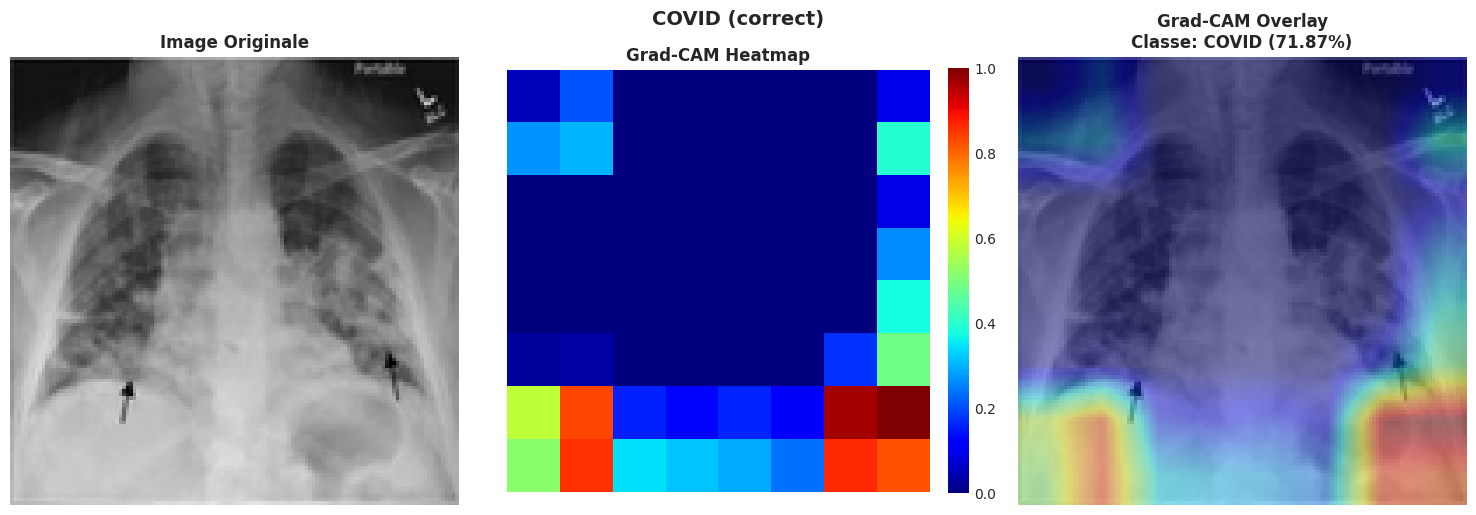


[2/3] COVID (correct)


   💾 Sauvegardé: gradcam_02.png


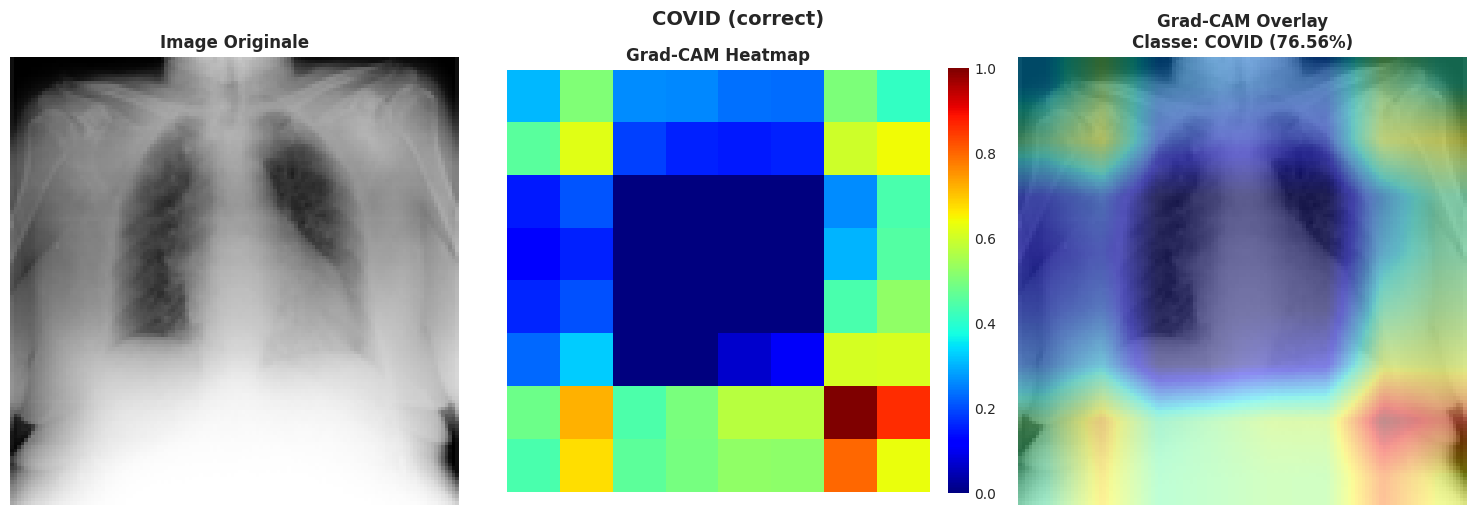


[3/3] Lung_Opacity (correct)
   💾 Sauvegardé: gradcam_03.png


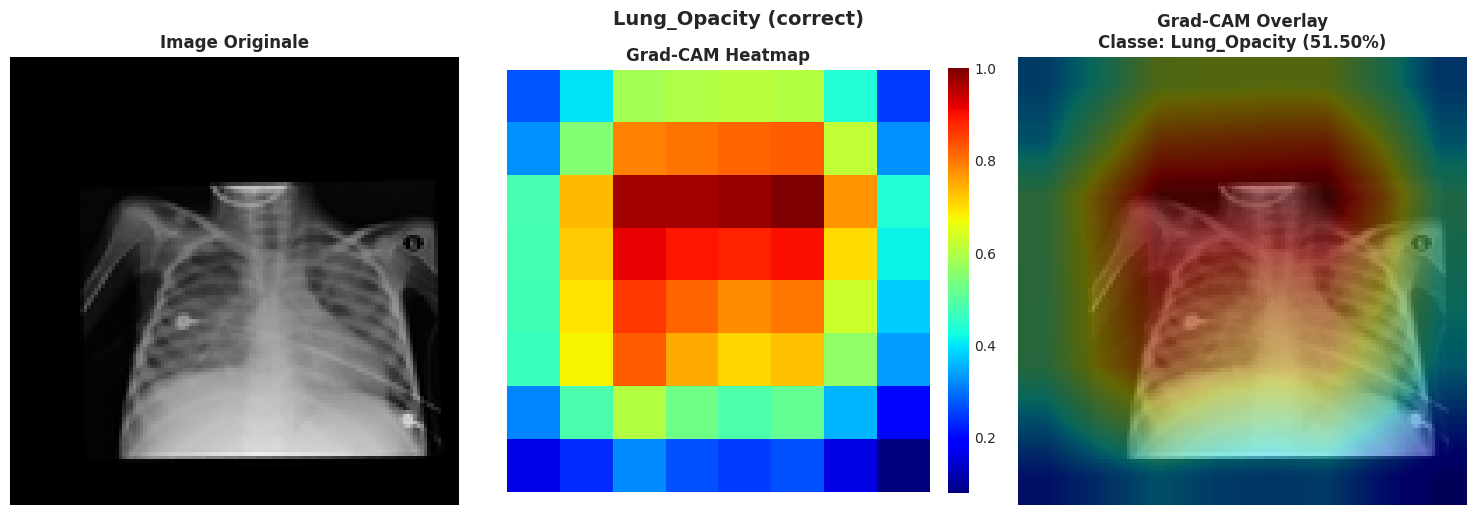


✅ Analyse Grad-CAM terminée!


In [ ]:
# Analyse Grad-CAM sur les échantillons correctement classifiés
interp_dir = plots_dir / 'gradcam_correct'
interp_dir.mkdir(parents=True, exist_ok=True)

run_gradcam_analysis(
    gradcam=gradcam,
    x_data=x_test,
    indices=indices_correct,
    descriptions=descriptions_correct,
    class_names=config.classes,
    y_pred_probs=y_pred_probs,
    save_dir=interp_dir
)

SÉLECTION D'ÉCHANTILLONS - INCORRECT

✅ 3 échantillons mal classifiés sélectionnés

📊 Résumé:
   Total: 3 échantillons
   • Lung_Opacity → COVID (incorrect): 1
   • Viral Pneumonia → COVID (incorrect): 1
   • Normal → COVID (incorrect): 1

📊 3 échantillons mal classifiés trouvés
ANALYSE GRAD-CAM - 3 ÉCHANTILLONS

💾 Sauvegarde dans: /content/Data_Pipeline/results/interpretability_custom_cnn/errors

[1/3] Normal → COVID (incorrect)
   💾 Sauvegardé: gradcam_01.png


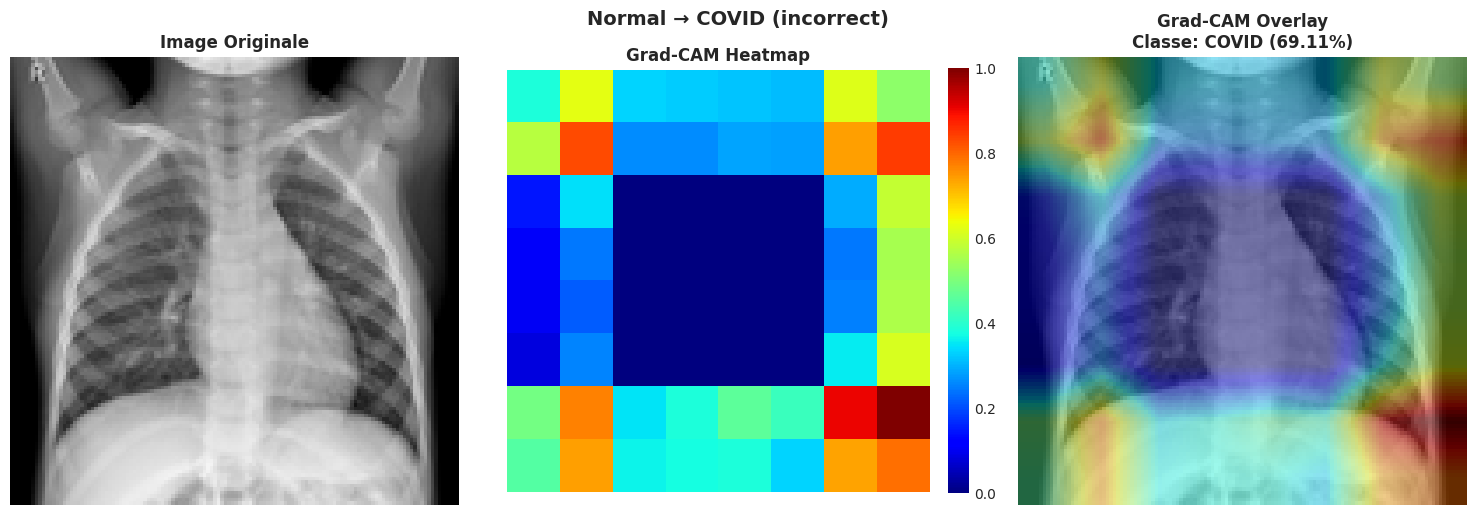


[2/3] Lung_Opacity → COVID (incorrect)
   💾 Sauvegardé: gradcam_02.png


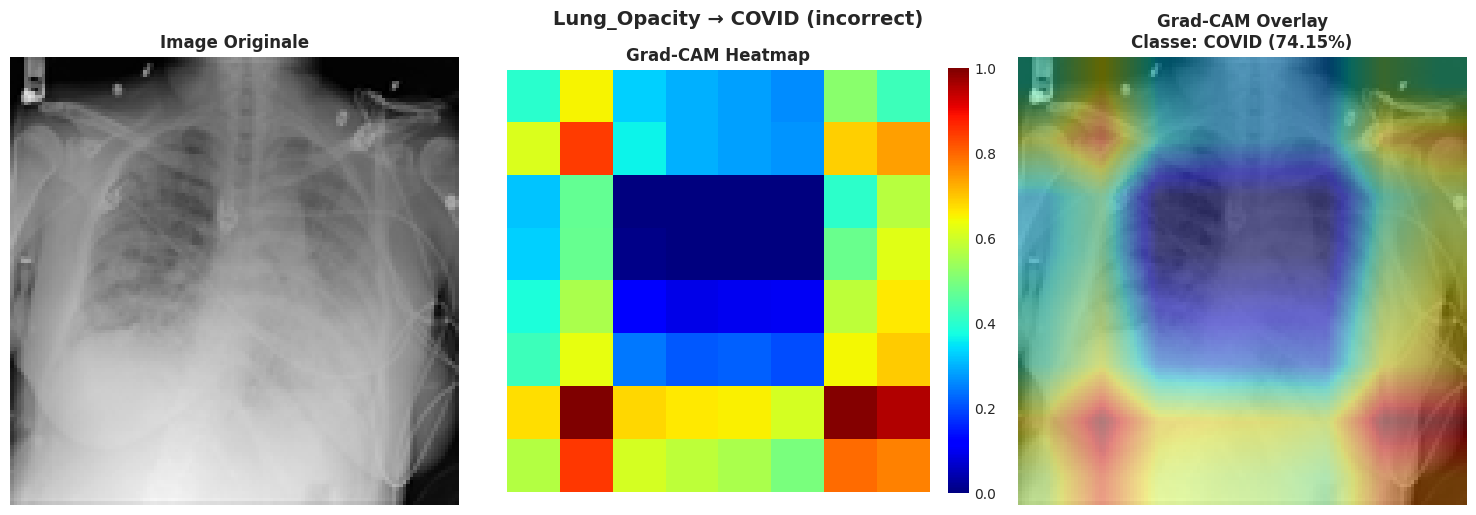


[3/3] Viral Pneumonia → COVID (incorrect)
   💾 Sauvegardé: gradcam_03.png


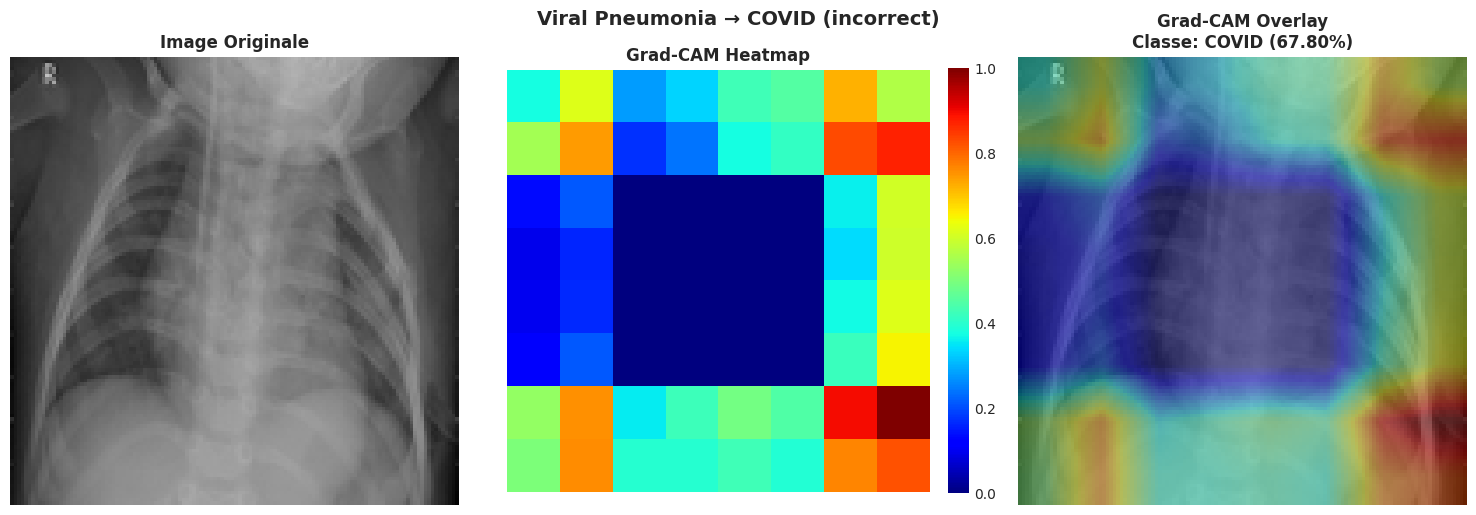


✅ Analyse Grad-CAM terminée!


In [ ]:
if len(indices_incorrect) > 0:
    # Analyse Grad-CAM sur les erreurs
    interp_dir_errors = plots_dir / 'gradcam_errors'
    interp_dir_errors.mkdir(parents=True, exist_ok=True)
    
    run_gradcam_analysis(
        gradcam=gradcam,
        x_data=x_test,
        indices=indices_incorrect,
        descriptions=descriptions_incorrect,
        class_names=config.classes,
        y_pred_probs=y_pred_probs,
        save_dir=interp_dir_errors
    )
else:
    print("\n✅ Aucune erreur trouvée (modèle parfait sur le test set!)")

## 7. Résumé

✅ Notebook d'interprétabilité pour **InceptionV3 pré-entraîné** !

### 🎯 Caractéristiques

1. **Modèle pré-entraîné** : Chargement d'InceptionV3 depuis `models/inceptionv3_best.keras`
2. **Images 224x224** : Taille requise pour InceptionV3
3. **Preprocessing spécifique** : Normalisation InceptionV3 ([-1, 1])
4. **Évaluation complète** : Métriques et matrice de confusion
5. **Grad-CAM** : Analyse des prédictions correctes et erreurs
6. **Variables snake_case** : Conformité avec les scripts refactorisés

### 📦 Modules utilisés

```
src/notebooks/
├── data_utils.py              # load_dataset, preprocessing, generators
├── training_utils.py          # evaluate_model
├── visualization_utils.py     # plot_confusion_matrix
└── interpretability_utils.py  # Grad-CAM analysis
```

### 🔍 Résultats générés

- **Matrice de confusion** : Performance globale du modèle
- **Grad-CAM correct** : Visualisation des zones d'attention pour les bonnes prédictions
- **Grad-CAM erreurs** : Analyse des cas d'erreur pour comprendre les faiblesses

In [ ]:
print("=" * 70)
print("🎉 ANALYSE TERMINÉE")
print("=" * 70)
print("\n✅ Modèle InceptionV3 évalué")
print("✅ Matrice de confusion générée")
print("✅ Grad-CAM analysé (correct + erreurs)")
print("\n📊 Résultats sauvegardés dans:")
print(f"   • Plots: {plots_dir}")
print(f"   • Grad-CAM correct: {interp_dir}")
if len(indices_incorrect) > 0:
    print(f"   • Grad-CAM erreurs: {interp_dir_errors}")

🎉 NOTEBOOK TERMINÉ

✅ Modèle entraîné et évalué
✅ Visualisations générées
✅ Interprétabilité analysée

📊 Résultats sauvegardés dans:
   • Modèles: /content/Data_Pipeline/results/custom_cnn_models
   • Plots: /content/Data_Pipeline/results/custom_cnn_plots
   • Grad-CAM: /content/Data_Pipeline/results/interpretability_custom_cnn
